# Beyond Hybrid Search with "Wormhole Vectors"

This notebook demonstrates the **Wormhole Vectors** technique for traversing between disjoint vector spaces:

1. **Sparse / Lexical space** — TF-IDF keyword matching (BM25-style)
2. **Dense / Semantic space** — Qwen3-8B sentence embeddings + cosine similarity
3. **Behavioral space** — Collaborative filtering latent features (ALS matrix factorization)

The core idea:
> *Query in one vector space → find top-K documents → pool their embeddings in a **target** space → use that pooled vector as a new query in the target space*

This pooled vector is the **wormhole** — a shortcut between distant regions of different vector spaces.

---

**Model:** `sentence-transformers/all-MiniLM-L6-v2` via `sentence-transformers` for dense embeddings. Can also use swap in `Qwen/Qwen3-0.6B` of `Qwen/Qwen3-8B` (requires 16BG+ memory allocated).


In [1]:
# ── Cell 1: Imports & configuration ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────────────────
# Swap MODEL_NAME to a smaller model for CPU / low-VRAM environments:
#   'Qwen/Qwen3-0.6B'                    (fast, CPU-friendly)
#   'sentence-transformers/all-MiniLM-L6-v2'  (384-dim, very fast)
#   'Qwen/Qwen3-8B'                       (best quality, needs ~16GB VRAM)
#MODEL_NAME = 'Qwen/Qwen3-8B'
#MODEL_NAME = 'Qwen/Qwen3-0.6B'
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

TOP_K      = 5      # docs to retrieve per query
WORMHOLE_K = 4      # docs whose embeddings we pool to form the wormhole vector
N_LATENT   = 20     # latent dimensions for behavioral space (ALS rank)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'Config: model={MODEL_NAME}, TOP_K={TOP_K}, WORMHOLE_K={WORMHOLE_K}, N_LATENT={N_LATENT}')

Config: model=sentence-transformers/all-MiniLM-L6-v2, TOP_K=5, WORMHOLE_K=4, N_LATENT=20


## 1  Document Corpus

We use a 30-document corpus spanning three thematic clusters — **machine learning**, **databases**, and **distributed systems** — with deliberate cross-cluster behavioural connections to make the wormhole traversals interesting.

In [2]:
# ── Cell 2: Corpus ───────────────────────────────────────────────────────────
CORPUS = [
    # Machine Learning
    {'id': 0,  'title': 'Neural Networks Fundamentals',
     'text': 'A neural network is a machine learning model composed of layers of interconnected neurons. Each layer applies a linear transformation followed by a non-linear activation function. During training, backpropagation computes gradients of the loss with respect to each parameter, and gradient descent updates weights to minimize the loss.',
     'category': 'ML'},
    {'id': 1,  'title': 'Transformer Architecture & Self-Attention',
     'text': 'Transformers use self-attention to relate positions in a sequence to each other. The attention mechanism computes query, key, and value projections, then scores each position against all others via scaled dot-product attention. Multi-head attention allows the model to attend to different representation subspaces simultaneously.',
     'category': 'ML'},
    {'id': 2,  'title': 'Gradient Descent Optimization Methods',
     'text': 'Gradient descent is an iterative optimization algorithm that updates model parameters in the direction of steepest descent of the loss function. Variants include SGD with momentum, RMSProp, and Adam. The learning rate controls the step size, and adaptive methods adjust it per-parameter.',
     'category': 'ML'},
    {'id': 3,  'title': 'Convolutional Neural Networks for Vision',
     'text': 'CNNs apply learned convolution filters to detect local spatial features in images. Pooling layers downsample feature maps to achieve translation invariance. Deep architectures like ResNet use skip connections to ease gradient flow through many layers.',
     'category': 'ML'},
    {'id': 4,  'title': 'Embedding Spaces and Semantic Search',
     'text': 'Embeddings map discrete objects such as words or documents into continuous vector spaces where geometric proximity reflects semantic similarity. Cosine similarity measures the angle between embedding vectors. Dense retrieval systems encode queries and documents into the same embedding space and retrieve via approximate nearest-neighbor search.',
     'category': 'ML'},
    {'id': 5,  'title': 'Recommendation Systems and Collaborative Filtering',
     'text': 'Collaborative filtering recommends items by finding users with similar interaction histories. Matrix factorization decomposes the user-item interaction matrix into low-rank user and item embedding matrices. Alternating Least Squares (ALS) is an efficient algorithm for this decomposition.',
     'category': 'ML'},
    {'id': 6,  'title': 'Recurrent Neural Networks and LSTMs',
     'text': 'RNNs process sequential data by maintaining a hidden state that is updated at each time step. LSTMs use gating mechanisms — input, forget, and output gates — to control information flow and mitigate vanishing gradients. They are used in language modeling, speech recognition, and time-series forecasting.',
     'category': 'ML'},
    {'id': 7,  'title': 'Generative Adversarial Networks',
     'text': 'GANs consist of a generator that produces synthetic samples and a discriminator that distinguishes real from fake. The two networks are trained adversarially in a minimax game. Training instability can be mitigated with techniques like Wasserstein distance and gradient penalty.',
     'category': 'ML'},
    {'id': 8,  'title': 'Retrieval-Augmented Generation (RAG)',
     'text': 'RAG augments large language models with a retrieval step that fetches relevant documents from an external knowledge base at inference time. The retrieved context is concatenated with the user query before generation. Dense retrieval with approximate nearest-neighbor search is a common retrieval backbone.',
     'category': 'ML'},
    {'id': 9,  'title': 'Sparse and Dense Hybrid Search',
     'text': 'Hybrid search combines lexical retrieval such as BM25 with dense vector retrieval. Reciprocal Rank Fusion merges the ranked lists from both systems. This approach captures both exact keyword matches and semantic similarity, outperforming either method alone on many benchmarks.',
     'category': 'ML'},
    # Databases
    {'id': 10, 'title': 'SQL Query Optimization',
     'text': 'Query optimizers transform SQL statements into efficient execution plans. They estimate the cost of alternative plans using statistics about table cardinalities and index selectivity. Common optimizations include predicate pushdown, join reordering, and index scans instead of full table scans.',
     'category': 'DB'},
    {'id': 11, 'title': 'B-Tree Index Structures',
     'text': 'B-trees are balanced search trees used as the primary index structure in relational databases. Each node stores sorted keys and child pointers. B+ trees store all records in leaf nodes linked in a sorted chain, enabling efficient range scans in addition to point lookups.',
     'category': 'DB'},
    {'id': 12, 'title': 'ACID Transaction Guarantees',
     'text': 'ACID properties — atomicity, consistency, isolation, and durability — ensure reliable transaction processing. Atomicity is enforced via write-ahead logging and rollback. Isolation levels from Read Committed to Serializable trade concurrency for anomaly protection.',
     'category': 'DB'},
    {'id': 13, 'title': 'NoSQL Document Store Design',
     'text': 'Document stores such as MongoDB persist schema-flexible JSON documents. Indexes on nested fields enable efficient queries. Denormalization trades write amplification for fast read paths. Horizontal sharding distributes documents across nodes by a shard key.',
     'category': 'DB'},
    {'id': 14, 'title': 'Graph Database Models',
     'text': 'Graph databases represent data as nodes and edges with properties. Traversal queries follow edges to discover multi-hop relationships. The Cypher query language expresses graph pattern matching declaratively. Native graph storage uses index-free adjacency for O(1) edge traversal.',
     'category': 'DB'},
    {'id': 15, 'title': 'Inverted Index for Full-Text Search',
     'text': 'An inverted index maps each term to the list of documents containing it, along with term frequency and positional information. BM25 scores documents by term frequency normalized by document length and inverse document frequency. Lucene and Elasticsearch are built on this structure.',
     'category': 'DB'},
    {'id': 16, 'title': 'Column-Oriented Analytical Databases',
     'text': 'Columnar databases store each column contiguously on disk, enabling vectorized scans over a single column without reading unneeded attributes. Run-length encoding and dictionary encoding compress repeated values. Systems like DuckDB and ClickHouse are designed for analytical workloads.',
     'category': 'DB'},
    {'id': 17, 'title': 'Vector Databases and ANN Search',
     'text': 'Vector databases store embedding vectors and answer approximate nearest-neighbor queries. HNSW builds a hierarchical proximity graph for sub-linear search. IVF partitions the space into clusters and probes only nearby clusters at query time. Systems like Qdrant, Weaviate, and Pinecone implement these indexes.',
     'category': 'DB'},
    {'id': 18, 'title': 'Database Replication and WAL',
     'text': 'Write-ahead logging ensures durability by recording changes to a sequential log before applying them. Streaming replication ships WAL records to standby replicas for high availability. Logical replication decodes WAL to row-level change events that can fan out to heterogeneous subscribers.',
     'category': 'DB'},
    {'id': 19, 'title': 'Consistent Hashing for Data Partitioning',
     'text': 'Consistent hashing places both nodes and keys on a virtual ring so that adding or removing a node remaps only a fraction of keys. Virtual nodes improve load balance by giving each physical node multiple ring positions. Dynamo-style systems use this for replication and partitioning.',
     'category': 'DB'},
    # Distributed Systems
    {'id': 20, 'title': 'CAP Theorem and Distributed Trade-offs',
     'text': 'The CAP theorem states that a distributed system can guarantee at most two of consistency, availability, and partition tolerance simultaneously. In practice partition tolerance is unavoidable, so designers choose between CP systems like HBase and AP systems like Cassandra.',
     'category': 'SYS'},
    {'id': 21, 'title': 'Kubernetes Container Orchestration',
     'text': 'Kubernetes manages containerized workloads across a cluster of nodes. The control plane schedules pods onto nodes based on resource requests. Services provide stable DNS endpoints, and Ingress controllers route external traffic. Horizontal pod autoscaling adjusts replicas based on CPU or custom metrics.',
     'category': 'SYS'},
    {'id': 22, 'title': 'Microservices and Service Mesh',
     'text': 'Microservices decompose an application into small, independently deployable services communicating over APIs. A service mesh like Istio intercepts all inter-service traffic via sidecar proxies to enforce mutual TLS, circuit breaking, and distributed tracing without application-level changes.',
     'category': 'SYS'},
    {'id': 23, 'title': 'Object Storage Architecture',
     'text': 'Object stores like S3 persist data as immutable objects identified by a flat key namespace. Eventual consistency is the default for bucket listings; strong consistency was added for object PUTs and GETs in 2020. Lifecycle policies expire or transition objects to cheaper storage tiers.',
     'category': 'SYS'},
    {'id': 24, 'title': 'Raft Consensus Algorithm',
     'text': 'Raft elects a leader that serializes all writes as log entries and replicates them to a quorum of followers. Leader election uses randomized timeouts to avoid split votes. Log compaction via snapshotting keeps storage bounded without losing committed state.',
     'category': 'SYS'},
    {'id': 25, 'title': 'Event-Driven Architecture and Kafka',
     'text': 'Apache Kafka is a distributed log where producers append records to partitioned topics and consumers read at their own pace by tracking offsets. Compacted topics retain the latest record per key indefinitely. Kafka Streams enables stateful stream processing on top of the log.',
     'category': 'SYS'},
    {'id': 26, 'title': 'gRPC and Protocol Buffers',
     'text': 'gRPC uses HTTP/2 for multiplexed, bidirectional streaming RPCs. Protocol Buffers define a strongly-typed schema from which code is generated in multiple languages. Field tags allow backward-compatible schema evolution. gRPC is widely used for low-latency inter-service communication.',
     'category': 'SYS'},
    {'id': 27, 'title': 'Content Delivery Networks',
     'text': 'CDNs cache static assets at edge nodes close to end users to reduce origin load and latency. Cache-Control headers govern TTLs. Cache invalidation propagates purge requests to all edges. Some CDNs support edge compute for running lightweight functions at the edge without round-tripping to origin.',
     'category': 'SYS'},
    {'id': 28, 'title': 'Load Balancing Algorithms',
     'text': 'Load balancers distribute traffic across backend instances. Round-robin is simple but ignores instance load. Least-connections routes to the server with fewest active requests. Consistent hashing with bounded loads is used for cache-affinity routing. Health checks remove unhealthy backends from the pool.',
     'category': 'SYS'},
    {'id': 29, 'title': 'Distributed Tracing and Observability',
     'text': 'Distributed tracing propagates a trace context through all services handling a request, recording spans with timing and metadata. Jaeger and Zipkin visualize trace waterfalls for latency analysis. OpenTelemetry is the emerging standard for instrumentation across logs, metrics, and traces.',
     'category': 'SYS'},
]

df = pd.DataFrame(CORPUS)
print(f'Corpus: {len(df)} documents across {df.category.nunique()} categories')
df.groupby('category').size().rename('count').to_frame()

Corpus: 30 documents across 3 categories


,count
category,
DB,10
ML,10
SYS,10


## 2  Space 1: Sparse / Lexical Vector Space

We build a **TF-IDF inverted index** over the corpus. Each document is a sparse vector with one dimension per vocabulary term, weighted by TF-IDF. Queries are also vectorized with the same scheme and cosine similarity retrieves the top-K documents.

> *In Trey's slides, this is the "Sparse Lexical Vector Space" on the left of the wormhole diagram.*

In [3]:
# ── Cell 3: Sparse space (TF-IDF) ────────────────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000,
    stop_words='english',
    sublinear_tf=True,
)
sparse_matrix = tfidf.fit_transform(df['text'])   # shape: (n_docs, vocab)
vocab = tfidf.get_feature_names_out()
print(f'Sparse space: {sparse_matrix.shape[0]} docs × {sparse_matrix.shape[1]} terms')
print(f'Sparsity: {1 - sparse_matrix.nnz / (sparse_matrix.shape[0]*sparse_matrix.shape[1]):.3f}')

def sparse_search(query: str, top_k: int = TOP_K):
    """BM25-style TF-IDF retrieval."""
    qvec = tfidf.transform([query])
    scores = cosine_similarity(qvec, sparse_matrix).flatten()
    ranked = np.argsort(scores)[::-1][:top_k]
    return [(int(i), float(scores[i])) for i in ranked]

# Quick smoke-test
results = sparse_search('neural network layers activation')
print('\nSparse search: "neural network layers activation"')
for doc_id, score in results:
    print(f'  [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}')

Sparse space: 30 docs × 1457 terms
Sparsity: 0.962

Sparse search: "neural network layers activation"
  [0.2857] (ML) Neural Networks Fundamentals
  [0.0827] (ML) Convolutional Neural Networks for Vision
  [0.0000] (SYS) Load Balancing Algorithms
  [0.0000] (ML) Transformer Architecture & Self-Attention
  [0.0000] (ML) Gradient Descent Optimization Methods


## 3  Space 2: Dense / Semantic Vector Space

We use **Qwen3-8B** to produce 4096-dim sentence embeddings. The model is loaded in half-precision and (if available) moved to GPU. For CPU-only environments, set `MODEL_NAME = 'Qwen/Qwen3-0.6B'` or `'sentence-transformers/all-MiniLM-L6-v2'` in Cell 1.

We embed all 30 documents once and cache them. Query embedding happens at search time.

In [4]:
# ── Cell 4: Load Qwen3 embedding model ──────────────────────────────────────
import torch
from transformers import AutoTokenizer, AutoModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

print(f'Loading {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
embed_model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
).to(DEVICE).eval()
print('Model loaded.')

def mean_pool(model_output, attention_mask):
    """Mean-pool last hidden states, respecting padding."""
    token_emb = model_output.last_hidden_state          # (B, T, H)
    mask = attention_mask.unsqueeze(-1).float()         # (B, T, 1)
    return (token_emb * mask).sum(1) / mask.sum(1)      # (B, H)

def embed_texts(texts: list[str], batch_size: int = 4) -> np.ndarray:
    """Return L2-normalised embeddings, shape (len(texts), hidden_size)."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True,
                        truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad():
            out = embed_model(**enc)
        emb = mean_pool(out, enc['attention_mask']).cpu().float().numpy()
        all_embs.append(emb)
    vecs = np.vstack(all_embs)
    return normalize(vecs, norm='l2')   # unit-norm for cosine via dot-product

print('Testing embed_texts ...')
test_emb = embed_texts(['hello world'])
print(f'Embedding dim: {test_emb.shape[1]}')

Using device: cpu
Loading sentence-transformers/all-MiniLM-L6-v2 ...


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Model loaded.
Testing embed_texts ...
Embedding dim: 384


In [5]:
# ── Cell 5: Embed the full corpus (runs once, ~1-2 min on GPU) ───────────────
print('Embedding corpus ...')
dense_matrix = embed_texts(df['text'].tolist())   # (30, H)
print(f'Dense matrix shape: {dense_matrix.shape}')

def dense_search(query: str, top_k: int = TOP_K):
    """Semantic nearest-neighbour retrieval."""
    qvec = embed_texts([query])                        # (1, H)
    scores = (dense_matrix @ qvec.T).flatten()         # dot product = cosine (unit-norm)
    ranked = np.argsort(scores)[::-1][:top_k]
    return [(int(i), float(scores[i])) for i in ranked]

results = dense_search('attention mechanism in transformers')
print('\nDense search: "attention mechanism in transformers"')
for doc_id, score in results:
    print(f'  [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}')

Embedding corpus ...
Dense matrix shape: (30, 384)

Dense search: "attention mechanism in transformers"
  [0.7757] (ML) Transformer Architecture & Self-Attention
  [0.2891] (ML) Recurrent Neural Networks and LSTMs
  [0.2454] (ML) Convolutional Neural Networks for Vision
  [0.1763] (ML) Retrieval-Augmented Generation (RAG)
  [0.1649] (ML) Neural Networks Fundamentals


## 4  Space 3: Behavioral Vector Space

We simulate a **user-item interaction matrix** in which users co-read documents within and across clusters, then run **Alternating Least Squares (ALS)** matrix factorization to produce latent item embeddings.

These latent embeddings capture *behavioural similarity* — documents that users tend to read together will be close in this space even if they share no terms and have dissimilar text embeddings.

> *In production, replace `simulate_interactions()` with real click/purchase/dwell-time logs.*

In [6]:
# ── Cell 6: Simulate user-item interactions ───────────────────────────────────
N_USERS = 200

def simulate_interactions(n_users: int, n_docs: int, seed: int = RANDOM_SEED):
    """
    Simulate plausible reading sessions.
    Users are assigned a primary interest cluster; they read 4-8 docs from
    their cluster and 1-2 cross-cluster docs (e.g. an ML researcher also
    reads about vector databases and Kafka).
    Returns a dense (n_users, n_docs) implicit feedback matrix.
    """
    rng = np.random.default_rng(seed)
    cats = df['category'].values
    cat_ids = {c: np.where(cats == c)[0] for c in ['ML','DB','SYS']}

    # Hand-crafted cross-cluster affinities (mirrors real reading patterns)
    cross = {
        'ML':  np.array([17, 15, 9, 25]),   # ML folks also read: vector DBs, inverted index, hybrid search, Kafka
        'DB':  np.array([4,  5,  9, 19]),    # DB folks also read: embeddings, collab filter, hybrid search, consistent hashing
        'SYS': np.array([10, 17, 16, 8]),    # SYS folks also read: SQL opt, vector DB, columnar, RAG
    }
    cat_list = ['ML','DB','SYS']
    R = np.zeros((n_users, n_docs), dtype=np.float32)
    for u in range(n_users):
        primary = cat_list[u % 3]
        # Primary-cluster docs
        pool = cat_ids[primary]
        n_primary = rng.integers(4, min(9, len(pool)+1))
        chosen = rng.choice(pool, size=n_primary, replace=False)
        R[u, chosen] = rng.integers(3, 11, size=len(chosen)).astype(float)
        # Cross-cluster docs
        cx = cross[primary]
        n_cross = rng.integers(1, 4)
        cx_chosen = rng.choice(cx, size=min(n_cross, len(cx)), replace=False)
        R[u, cx_chosen] = rng.integers(2, 8, size=len(cx_chosen)).astype(float)
    return R

R = simulate_interactions(N_USERS, len(df))
print(f'Interaction matrix shape : {R.shape}')
print(f'Density                  : {(R > 0).mean():.3f}')
print(f'Mean interactions / user : {(R > 0).sum(1).mean():.1f}')

Interaction matrix shape : (200, 30)
Density                  : 0.264
Mean interactions / user : 7.9


In [7]:
# ── Cell 7: ALS matrix factorization ─────────────────────────────────────────
# We implement a lightweight ALS solver without the `implicit` library
# so students don't need an extra install.  Swap for implicit.als.AlternatingLeastSquares
# in production for better performance and confidence weighting.

def als_fit(R: np.ndarray, rank: int = N_LATENT, n_iter: int = 20, reg: float = 0.1):
    """
    Simple ALS for implicit feedback.
    Returns U (n_users, rank) and V (n_items, rank), both L2-normalised.
    """
    n_users, n_items = R.shape
    rng = np.random.default_rng(RANDOM_SEED)
    U = rng.standard_normal((n_users, rank)).astype(np.float32) * 0.01
    V = rng.standard_normal((n_items, rank)).astype(np.float32) * 0.01
    I_reg = reg * np.eye(rank, dtype=np.float32)

    for it in range(n_iter):
        # Fix V, solve for U
        VtV = V.T @ V + I_reg
        for u in range(n_users):
            r = R[u]                   # (n_items,)
            mask = r > 0
            if not mask.any(): continue
            Vr = V[mask]               # (nnz, rank)
            rr = r[mask]               # (nnz,)
            A  = Vr.T @ (rr[:, None] * Vr) + I_reg
            b  = Vr.T @ rr
            U[u] = np.linalg.solve(A, b)
        # Fix U, solve for V
        UtU = U.T @ U + I_reg
        for i in range(n_items):
            r = R[:, i]                # (n_users,)
            mask = r > 0
            if not mask.any(): continue
            Ur = U[mask]
            rr = r[mask]
            A  = Ur.T @ (rr[:, None] * Ur) + I_reg
            b  = Ur.T @ rr
            V[i] = np.linalg.solve(A, b)
        if (it + 1) % 5 == 0:
            recon = U @ V.T
            mask  = R > 0
            rmse  = np.sqrt(((recon[mask] - R[mask])**2).mean())
            print(f'  Iter {it+1:3d} | RMSE = {rmse:.4f}')

    return normalize(U, norm='l2'), normalize(V, norm='l2')

print('Running ALS ...')
U_latent, V_latent = als_fit(R)   # V_latent shape: (n_docs, N_LATENT)
print(f'\nItem (doc) latent matrix shape: {V_latent.shape}')

def behavioral_search(query_vec: np.ndarray, top_k: int = TOP_K):
    """Search the behavioral space given a latent query vector."""
    scores = (V_latent @ query_vec).flatten()
    ranked = np.argsort(scores)[::-1][:top_k]
    return [(int(i), float(scores[i])) for i in ranked]

Running ALS ...
  Iter   5 | RMSE = 5.4070
  Iter  10 | RMSE = 5.4071
  Iter  15 | RMSE = 5.4072
  Iter  20 | RMSE = 5.4073

Item (doc) latent matrix shape: (30, 20)


## 5  Wormhole Vector Generation

The wormhole algorithm (from slide 30):

1. Query in the **source** vector space → retrieve top-K documents
2. Look up those documents' embeddings in the **target** space
3. **Average** (pool) those embeddings → the **wormhole vector**
4. Use the wormhole vector as a query in the target space
5. Repeat across as many spaces as desired


In [8]:
# ── Cell 8: Wormhole vector utilities ────────────────────────────────────────

def pool_embeddings(doc_ids: list[int], matrix: np.ndarray,
                    weights: list[float] | None = None) -> np.ndarray:
    """
    Pool embeddings of selected docs from `matrix`.
    weights: if provided, weighted average (e.g. by retrieval score).
    Returns a single L2-normalised vector.
    """
    vecs = matrix[doc_ids]                # (k, dim)
    if weights is not None:
        w = np.array(weights, dtype=np.float32)
        w /= w.sum()
        pooled = (vecs * w[:, None]).sum(0)
    else:
        pooled = vecs.mean(0)
    norm = np.linalg.norm(pooled)
    return pooled / norm if norm > 0 else pooled

def wormhole_traverse(
    query: str,
    source_space: str = 'sparse',
    target_space: str = 'behavioral',
    wormhole_k: int = WORMHOLE_K,
    top_k: int = TOP_K,
    weighted: bool = True,
    verbose: bool = True,
):
    """
    Full wormhole traversal:
        source_space query  →  wormhole vector  →  target_space results

    Parameters
    ----------
    query        : natural-language query string
    source_space : 'sparse' | 'dense'
    target_space : 'behavioral' | 'dense' | 'sparse'
    wormhole_k   : how many top-source docs to pool
    top_k        : how many results to return from target space
    weighted     : if True, weight pooling by retrieval score
    verbose      : print step-by-step output

    Returns
    -------
    source_results  : list of (doc_id, score)
    wormhole_vec    : np.ndarray
    target_results  : list of (doc_id, score)
    """
    # Step 1: retrieve in source space
    if source_space == 'sparse':
        source_results = sparse_search(query, top_k=wormhole_k)
    elif source_space == 'dense':
        source_results = dense_search(query, top_k=wormhole_k)
    else:
        raise ValueError(f'Unknown source_space: {source_space}')

    source_ids    = [r[0] for r in source_results]
    source_scores = [r[1] for r in source_results]

    if verbose:
        print(f'── Step 1: {source_space.upper()} space query: "{query}"')
        for doc_id, score in source_results:
            print(f'   [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}')

    # Step 2: look up those docs in the target embedding space
    if target_space == 'behavioral':
        target_matrix = V_latent
    elif target_space == 'dense':
        target_matrix = dense_matrix
    elif target_space == 'sparse':
        target_matrix = sparse_matrix.toarray()
    else:
        raise ValueError(f'Unknown target_space: {target_space}')

    # Step 3: pool → wormhole vector
    wormhole_vec = pool_embeddings(
        source_ids, target_matrix,
        weights=source_scores if weighted else None
    )

    if verbose:
        print(f'\n── Step 2-3: wormhole vector pooled from {len(source_ids)} docs '
              f'in {target_space.upper()} space (dim={wormhole_vec.shape[0]})')

    # Step 4: search in target space
    if target_space == 'behavioral':
        target_results = behavioral_search(wormhole_vec, top_k=top_k)
    else:
        tgt_matrix = dense_matrix if target_space == 'dense' else sparse_matrix.toarray()
        scores = (tgt_matrix @ wormhole_vec).flatten()
        ranked = np.argsort(scores)[::-1][:top_k]
        target_results = [(int(i), float(scores[i])) for i in ranked]

    if verbose:
        print(f'\n── Step 4: {target_space.upper()} space results via wormhole vector')
        for doc_id, score in target_results:
            flag = ' ← NEW' if doc_id not in source_ids else ''
            print(f'   [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}{flag}')

    return source_results, wormhole_vec, target_results


# Demo traversal: sparse → behavioral
print('=' * 60)
print('DEMO: sparse → behavioral wormhole traversal')
print('=' * 60)
src, wvec, tgt = wormhole_traverse(
    'neural network training optimization',
    source_space='sparse',
    target_space='behavioral',
)

DEMO: sparse → behavioral wormhole traversal
── Step 1: SPARSE space query: "neural network training optimization"
   [0.2261] (ML) Neural Networks Fundamentals
   [0.0630] (ML) Gradient Descent Optimization Methods
   [0.0537] (ML) Generative Adversarial Networks
   [0.0000] (SYS) Load Balancing Algorithms

── Step 2-3: wormhole vector pooled from 4 docs in BEHAVIORAL space (dim=20)

── Step 4: BEHAVIORAL space results via wormhole vector
   [0.9625] (ML) Neural Networks Fundamentals
   [0.7668] (ML) Generative Adversarial Networks
   [0.7025] (ML) Recurrent Neural Networks and LSTMs ← NEW
   [0.6681] (ML) Transformer Architecture & Self-Attention ← NEW
   [0.6394] (ML) Convolutional Neural Networks for Vision ← NEW


## 6  Multi-Hop Traversal

The wormhole idea is composable: we can chain traversals across all three spaces.

In [9]:
# ── Cell 9: Multi-hop traversal ───────────────────────────────────────────────

def multi_hop_traverse(query: str, hops: list[tuple[str,str]], top_k=TOP_K, wormhole_k=WORMHOLE_K):
    """
    Chain multiple wormhole traversals.
    hops: list of (source_space, target_space) tuples.
    Returns a list of (hop_label, source_results, wormhole_vec, target_results).
    """
    all_hops = []
    current_query = query
    prev_wvec = None

    for hop_idx, (src, tgt) in enumerate(hops):
        label = f'Hop {hop_idx+1}: {src} → {tgt}'
        print(f'\n{"="*60}')
        print(label)
        print('='*60)

        if hop_idx == 0:
            src_res, wvec, tgt_res = wormhole_traverse(
                current_query, src, tgt, wormhole_k=wormhole_k, top_k=top_k
            )
        else:
            # Use the previous wormhole vector as the query proxy
            # Re-retrieve in the source space using cosine to the wormhole vec
            if src == 'behavioral':
                src_scores = (V_latent @ prev_wvec).flatten()
            elif src == 'dense':
                src_scores = (dense_matrix @ prev_wvec).flatten()
            else:
                src_scores = (sparse_matrix.toarray() @ prev_wvec).flatten()
            src_ranked = np.argsort(src_scores)[::-1][:wormhole_k]
            src_res = [(int(i), float(src_scores[i])) for i in src_ranked]
            src_ids = [r[0] for r in src_res]
            src_sc  = [r[1] for r in src_res]

            print(f'── Source ({src.upper()}) re-retrieval from previous wormhole:')
            for doc_id, score in src_res:
                print(f'   [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}')

            tgt_matrix = ({'behavioral': V_latent, 'dense': dense_matrix,
                           'sparse': sparse_matrix.toarray()})[tgt]
            wvec = pool_embeddings(src_ids, tgt_matrix, weights=src_sc)

            if tgt == 'behavioral':
                tgt_res = behavioral_search(wvec, top_k=top_k)
            else:
                tgt_sc = (tgt_matrix @ wvec).flatten()
                tgt_ranked = np.argsort(tgt_sc)[::-1][:top_k]
                tgt_res = [(int(i), float(tgt_sc[i])) for i in tgt_ranked]

            print(f'\n── Target ({tgt.upper()}) wormhole results:')
            for doc_id, score in tgt_res:
                print(f'   [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}')

        prev_wvec = wvec
        all_hops.append((label, src_res, wvec, tgt_res))

    return all_hops


hops = multi_hop_traverse(
    'vector similarity search and indexing',
    hops=[
        ('dense', 'behavioral'),    # Hop 1: dense → behavioral
        ('behavioral', 'sparse'),   # Hop 2: behavioral → sparse
    ]
)


Hop 1: dense → behavioral
── Step 1: DENSE space query: "vector similarity search and indexing"
   [0.6252] (DB) Vector Databases and ANN Search
   [0.5979] (ML) Embedding Spaces and Semantic Search
   [0.5605] (ML) Sparse and Dense Hybrid Search
   [0.4544] (DB) Inverted Index for Full-Text Search

── Step 2-3: wormhole vector pooled from 4 docs in BEHAVIORAL space (dim=20)

── Step 4: BEHAVIORAL space results via wormhole vector
   [0.7358] (DB) Inverted Index for Full-Text Search
   [0.7267] (ML) Sparse and Dense Hybrid Search
   [0.7225] (ML) Embedding Spaces and Semantic Search
   [0.7129] (DB) ACID Transaction Guarantees ← NEW
   [0.6985] (DB) NoSQL Document Store Design ← NEW

Hop 2: behavioral → sparse
── Source (BEHAVIORAL) re-retrieval from previous wormhole:
   [0.7358] (DB) Inverted Index for Full-Text Search
   [0.7267] (ML) Sparse and Dense Hybrid Search
   [0.7225] (ML) Embedding Spaces and Semantic Search
   [0.7129] (DB) ACID Transaction Guarantees

── Target (SPARSE)

## 7  Visualizations

### 7a  2-D projection of the three vector spaces

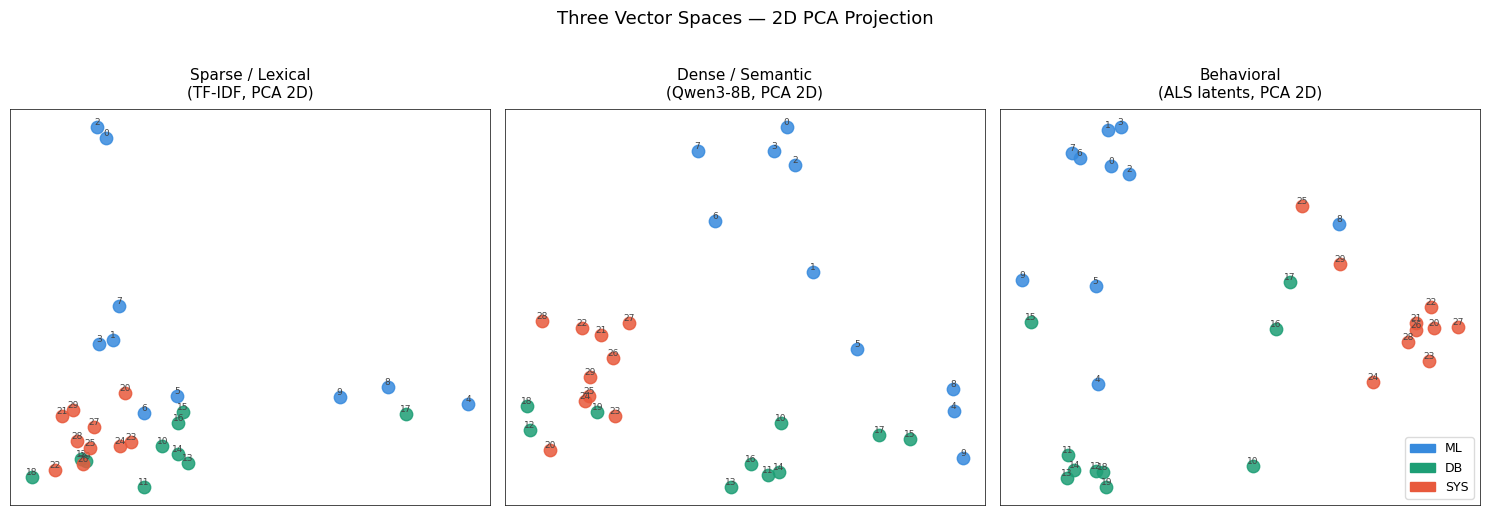

Saved spaces_2d.png


In [10]:
# ── Cell 10: 2-D projections of all three spaces ─────────────────────────────
from sklearn.decomposition import PCA

CAT_COLORS = {'ML': '#378add', 'DB': '#1D9E75', 'SYS': '#E8593C'}
cat_c = [CAT_COLORS[c] for c in df['category']]

def project_2d(matrix):
    m = matrix.toarray() if sp.issparse(matrix) else matrix
    return PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(normalize(m, norm='l2'))

proj_sparse     = project_2d(sparse_matrix)
proj_dense      = project_2d(dense_matrix)
proj_behavioral = project_2d(V_latent)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Sparse / Lexical\n(TF-IDF, PCA 2D)',
          'Dense / Semantic\n(Qwen3-8B, PCA 2D)',
          'Behavioral\n(ALS latents, PCA 2D)']
projs  = [proj_sparse, proj_dense, proj_behavioral]

for ax, proj, title in zip(axes, projs, titles):
    for cat, color in CAT_COLORS.items():
        mask = df['category'] == cat
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=color, label=cat, s=80, alpha=0.85, zorder=3)
        for idx in df[mask].index:
            ax.annotate(str(idx), (proj[idx,0], proj[idx,1]),
                        fontsize=6.5, ha='center', va='bottom', color='#444')
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_linewidth(0.5)

patches = [mpatches.Patch(color=c, label=l) for l, c in CAT_COLORS.items()]
axes[-1].legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.7)
plt.suptitle('Three Vector Spaces — 2D PCA Projection', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('spaces_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved spaces_2d.png')

### 7b  Wormhole traversal visualized as a flow diagram

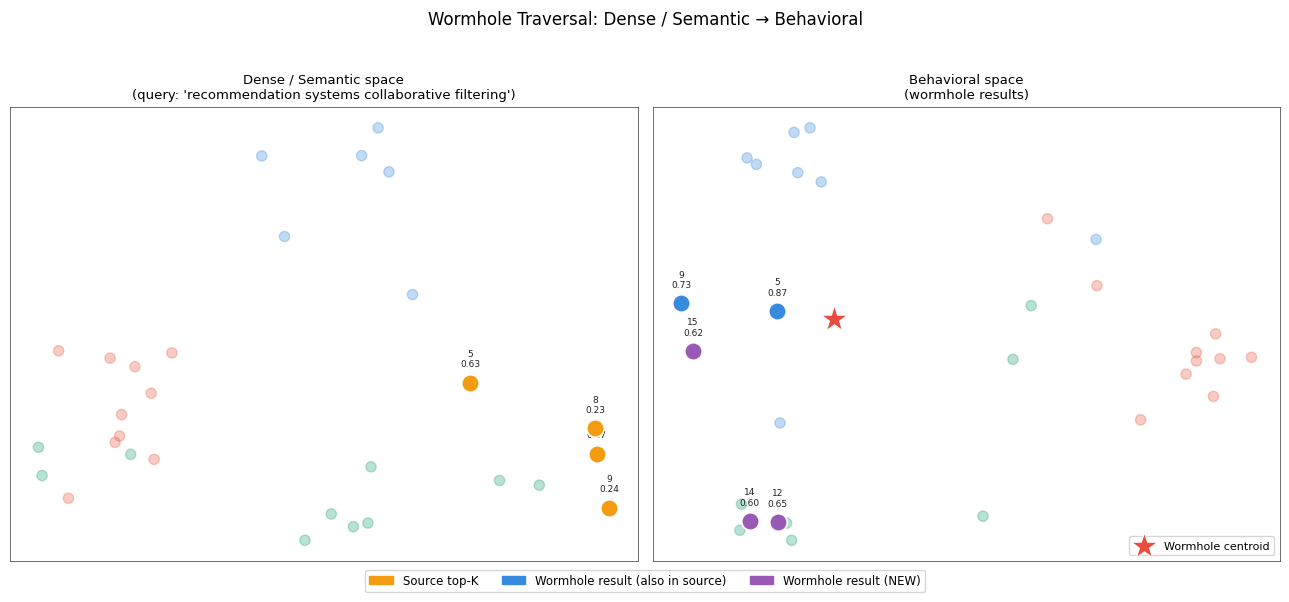

Saved wormhole_dense_to_behavioral.png


In [11]:
# ── Cell 11: Visualize a single wormhole traversal ───────────────────────────

def plot_wormhole(
    query: str,
    source_space: str = 'dense',
    target_space: str = 'behavioral',
    wormhole_k: int = WORMHOLE_K,
    top_k: int = TOP_K,
):
    src_res, wvec, tgt_res = wormhole_traverse(
        query, source_space, target_space,
        wormhole_k=wormhole_k, top_k=top_k, verbose=False
    )

    src_ids = {r[0] for r in src_res}
    tgt_ids = {r[0] for r in tgt_res}
    new_ids = tgt_ids - src_ids

    # Choose the right 2-D projection for each space
    proj_map = {'sparse': proj_sparse, 'dense': proj_dense, 'behavioral': proj_behavioral}
    src_proj = proj_map[source_space]
    tgt_proj = proj_map[target_space]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    space_labels = {'sparse': 'Sparse / Lexical', 'dense': 'Dense / Semantic', 'behavioral': 'Behavioral'}

    for ax, proj, space, results in [
        (axes[0], src_proj, source_space, src_res),
        (axes[1], tgt_proj, target_space, tgt_res),
    ]:
        res_ids = {r[0] for r in results}

        # Background: all docs
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[CAT_COLORS[c] for c in df['category']],
                   s=55, alpha=0.3, zorder=2)

        # Highlighted results
        for doc_id, score in results:
            is_new = (space == target_space) and (doc_id in new_ids)
            color  = '#9B59B6' if is_new else ('#F39C12' if space == source_space else '#378add')
            ax.scatter(proj[doc_id, 0], proj[doc_id, 1],
                       c=color, s=160, zorder=4,
                       edgecolors='white', linewidths=1.2)
            ax.annotate(
                f"{doc_id}\n{score:.2f}",
                (proj[doc_id, 0], proj[doc_id, 1]),
                fontsize=6.5, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points', color='#222'
            )

        # Wormhole centroid (in target space)
        if space == target_space:
            worm_proj = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(
                normalize(tgt_proj, norm='l2')
            ) if False else tgt_proj   # already projected; mark centroid differently
            # Mark pooled centroid on target plot via a star at average of source IDs in target proj
            cx = tgt_proj[list(src_ids), 0].mean()
            cy = tgt_proj[list(src_ids), 1].mean()
            ax.scatter(cx, cy, marker='*', s=400, c='#E74C3C', zorder=5,
                       edgecolors='white', linewidths=0.8, label='Wormhole centroid')
            ax.legend(fontsize=8, loc='lower right')

        ax.set_title(
            f'{space_labels[space]} space\n'
            f'({"query: " + repr(query) if space==source_space else "wormhole results"})'
            , fontsize=9.5, pad=6)
        ax.set_xticks([]); ax.set_yticks([])
        ax.spines[['top','right','left','bottom']].set_linewidth(0.4)

    # Legend for dot colors
    legend_items = [
        mpatches.Patch(color='#F39C12', label='Source top-K'),
        mpatches.Patch(color='#378add', label='Wormhole result (also in source)'),
        mpatches.Patch(color='#9B59B6', label='Wormhole result (NEW)'),
    ]
    fig.legend(handles=legend_items, loc='lower center', ncol=3, fontsize=8.5,
               framealpha=0.8, bbox_to_anchor=(0.5, -0.04))

    plt.suptitle(
        f'Wormhole Traversal: {space_labels[source_space]} → {space_labels[target_space]}',
        fontsize=12, y=1.03
    )
    plt.tight_layout()
    fname = f'wormhole_{source_space}_to_{target_space}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
    return src_res, wvec, tgt_res


src_res, wvec, tgt_res = plot_wormhole(
    'recommendation systems collaborative filtering',
    source_space='dense',
    target_space='behavioral',
)

### 7c  Score comparison: direct search vs wormhole search

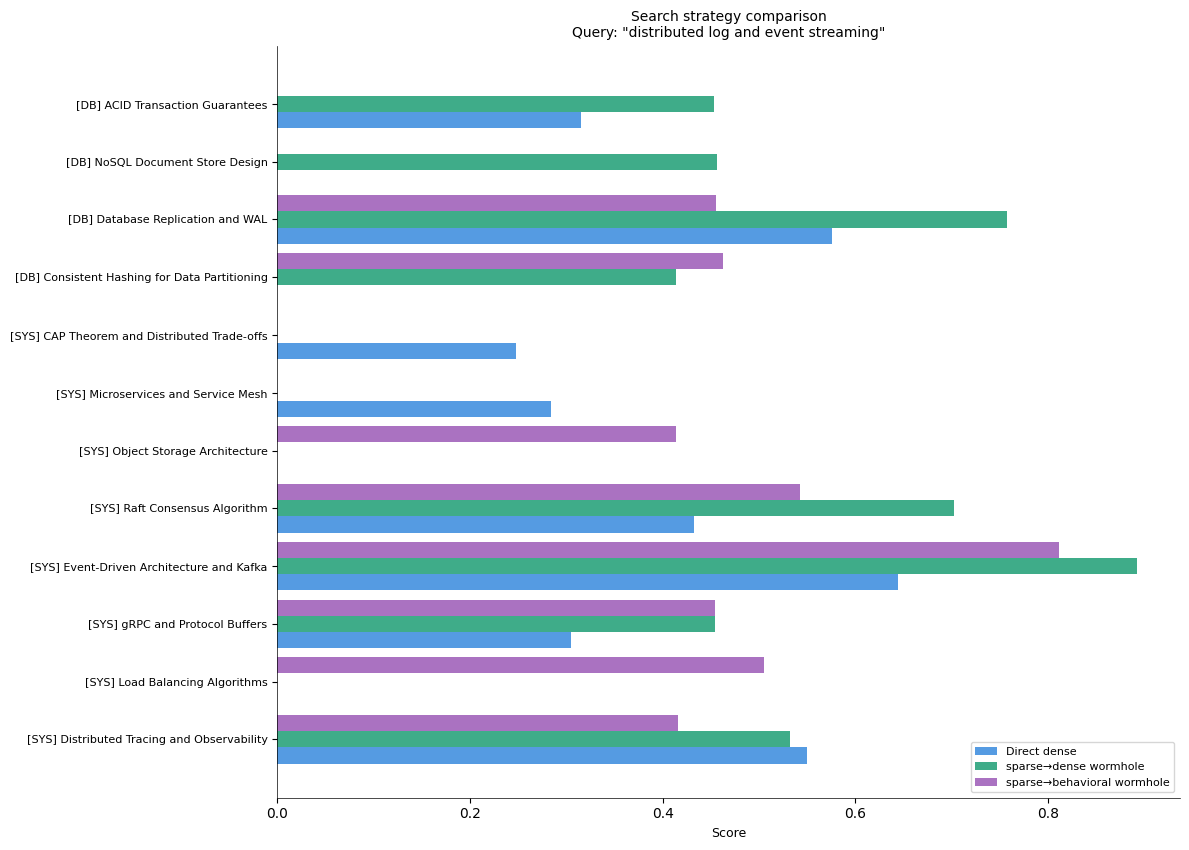

In [12]:
# ── Cell 12: Compare direct search vs wormhole search in target space ─────────

def compare_search_strategies(query: str, source_space: str = 'sparse', top_k: int = 8):
    """
    Compare:
      A) Direct semantic search in dense space
      B) Wormhole from source_space → dense
      C) Wormhole from source_space → behavioral
    """
    # A: direct dense
    direct = dense_search(query, top_k=top_k)

    # B: source → dense wormhole
    _, _, worm_dense = wormhole_traverse(
        query, source_space, 'dense',
        wormhole_k=WORMHOLE_K, top_k=top_k, verbose=False
    )

    # C: source → behavioral wormhole
    _, _, worm_beh = wormhole_traverse(
        query, source_space, 'behavioral',
        wormhole_k=WORMHOLE_K, top_k=top_k, verbose=False
    )

    all_ids = sorted(set(
        [r[0] for r in direct] +
        [r[0] for r in worm_dense] +
        [r[0] for r in worm_beh]
    ))

    def to_dict(results): return {r[0]: r[1] for r in results}
    da, db, dc = to_dict(direct), to_dict(worm_dense), to_dict(worm_beh)

    fig, ax = plt.subplots(figsize=(12, 0.55 * len(all_ids) + 2))
    y = np.arange(len(all_ids))
    bar_h = 0.28

    ax.barh(y + bar_h,  [da.get(i, 0) for i in all_ids], bar_h, label='Direct dense',            color='#378add', alpha=0.85)
    ax.barh(y,          [db.get(i, 0) for i in all_ids], bar_h, label=f'{source_space}→dense wormhole', color='#1D9E75', alpha=0.85)
    ax.barh(y - bar_h,  [dc.get(i, 0) for i in all_ids], bar_h, label=f'{source_space}→behavioral wormhole', color='#9B59B6', alpha=0.85)

    labels = [f'[{df.loc[i,"category"]}] {df.loc[i,"title"]}' for i in all_ids]
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Score', fontsize=9)
    ax.set_title(f'Search strategy comparison\nQuery: "{query}"', fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_linewidth(0.5)
    plt.tight_layout()
    plt.savefig('search_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

compare_search_strategies(
    'distributed log and event streaming',
    source_space='sparse',
)

### 7d  Cosine similarity heatmap across all three spaces

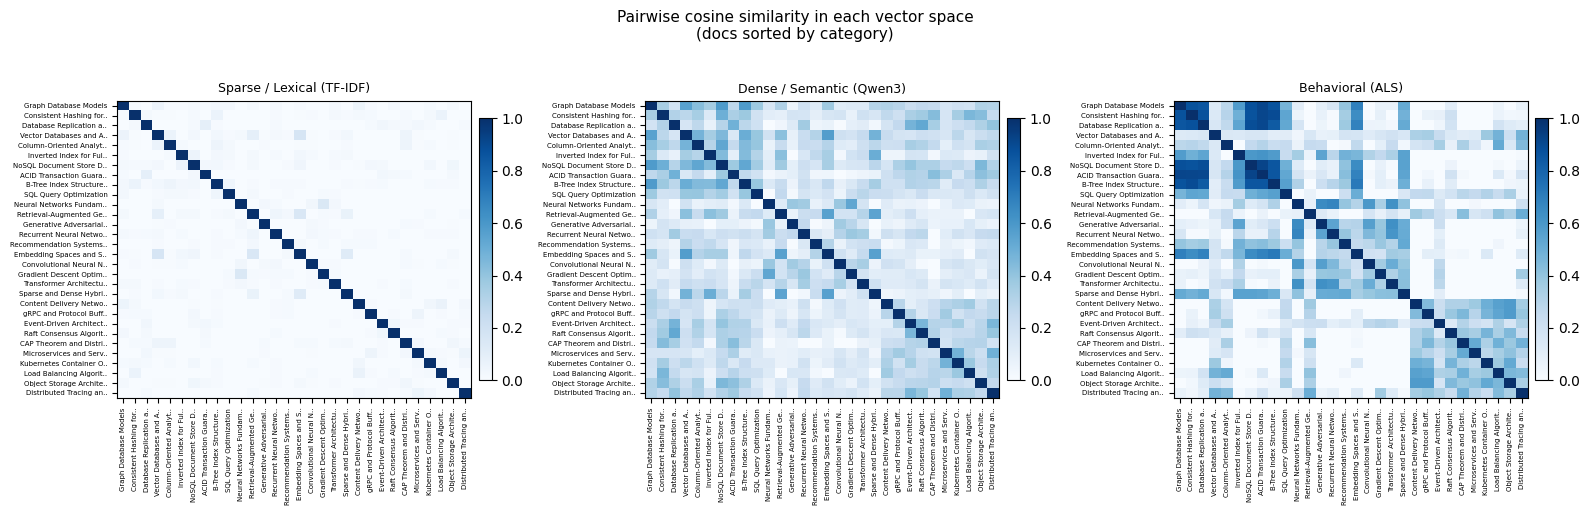

Saved similarity_heatmaps.png


In [13]:
# ── Cell 13: Similarity heatmaps ─────────────────────────────────────────────

def sim_matrix(matrix):
    m = normalize(matrix.toarray() if sp.issparse(matrix) else matrix, norm='l2')
    return m @ m.T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
space_names = ['Sparse / Lexical (TF-IDF)', 'Dense / Semantic (Qwen3)', 'Behavioral (ALS)']
matrices    = [sparse_matrix, dense_matrix, V_latent]

cat_order = df.sort_values('category').index.tolist()
cat_ticks = [df.loc[i,'title'][:22] + '..' if len(df.loc[i,'title'])>22 else df.loc[i,'title'] for i in cat_order]

for ax, mat, name in zip(axes, matrices, space_names):
    S = sim_matrix(mat)[np.ix_(cat_order, cat_order)]
    im = ax.imshow(S, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(cat_order))); ax.set_xticklabels(cat_ticks, rotation=90, fontsize=5)
    ax.set_yticks(range(len(cat_order))); ax.set_yticklabels(cat_ticks, fontsize=5)
    ax.set_title(name, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)

plt.suptitle('Pairwise cosine similarity in each vector space\n(docs sorted by category)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('similarity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved similarity_heatmaps.png')

## 8  Interactive Exploration Widget

Run the cell below to get a dropdown+text-input interface for exploring any query across all three spaces and generating wormhole vectors interactively.

In [14]:
# ── Cell 14: Interactive widget ──────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

query_input = widgets.Text(
    value='machine learning optimization',
    description='Query:',
    layout=widgets.Layout(width='55%'),
    style={'description_width': '60px'},
)
source_dd = widgets.Dropdown(
    options=['sparse', 'dense'],
    value='dense',
    description='From:',
    layout=widgets.Layout(width='160px'),
    style={'description_width': '40px'},
)
target_dd = widgets.Dropdown(
    options=['behavioral', 'dense', 'sparse'],
    value='behavioral',
    description='To:',
    layout=widgets.Layout(width='180px'),
    style={'description_width': '35px'},
)
k_slider = widgets.IntSlider(
    value=WORMHOLE_K, min=2, max=10, step=1,
    description='Wormhole K:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='280px'),
)
run_btn = widgets.Button(
    description='Generate Wormhole →',
    button_style='primary',
    layout=widgets.Layout(width='190px'),
)
out = widgets.Output()

def on_run(b):
    with out:
        clear_output(wait=True)
        src, wv, tgt = plot_wormhole(
            query_input.value,
            source_space=source_dd.value,
            target_space=target_dd.value,
            wormhole_k=k_slider.value,
        )
        print('\n── Source results:')
        for doc_id, score in src:
            print(f'  [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}')
        print('\n── Target (wormhole) results:')
        for doc_id, score in tgt:
            flag = ' ← NEW' if doc_id not in {r[0] for r in src} else ''
            print(f'  [{score:.4f}] ({df.loc[doc_id,"category"]}) {df.loc[doc_id,"title"]}{flag}')

run_btn.on_click(on_run)

display(
    widgets.VBox([
        widgets.HTML('<b>Wormhole Vector Explorer</b>'),
        widgets.HBox([query_input]),
        widgets.HBox([source_dd, target_dd, k_slider]),
        run_btn,
        out,
    ])
)

## 9  Exercises

Work through these to deepen your understanding.

### Exercise 1 — Weighted vs unweighted pooling

In `pool_embeddings`, we optionally weight each document's embedding by its retrieval score. Does weighting improve the wormhole quality? Modify `wormhole_traverse` to compare both approaches and check whether the top-5 wormhole results differ.

In [15]:
# Exercise 1 starter
query = 'attention mechanism transformer'

_, wvec_weighted,   tgt_w  = wormhole_traverse(query, 'dense', 'behavioral', weighted=True,  verbose=False)
_, wvec_unweighted, tgt_uw = wormhole_traverse(query, 'dense', 'behavioral', weighted=False, verbose=False)

print('Weighted pooling results:')
for doc_id, score in tgt_w:
    print(f'  [{score:.4f}] {df.loc[doc_id,"title"]}')

print('\nUnweighted pooling results:')
for doc_id, score in tgt_uw:
    print(f'  [{score:.4f}] {df.loc[doc_id,"title"]}')

print(f'\nCosine similarity between the two wormhole vectors: {float(wvec_weighted @ wvec_unweighted):.4f}')

Weighted pooling results:
  [0.9277] Transformer Architecture & Self-Attention
  [0.8034] Neural Networks Fundamentals
  [0.7945] Recurrent Neural Networks and LSTMs
  [0.7138] Generative Adversarial Networks
  [0.7026] Convolutional Neural Networks for Vision

Unweighted pooling results:
  [0.8758] Neural Networks Fundamentals
  [0.8295] Transformer Architecture & Self-Attention
  [0.8262] Recurrent Neural Networks and LSTMs
  [0.7733] Convolutional Neural Networks for Vision
  [0.7226] Generative Adversarial Networks

Cosine similarity between the two wormhole vectors: 0.9768


### Exercise 2 — Effect of wormhole K

How does the number of pooled documents (K) affect the wormhole vector? A very small K (1-2) gives a sharp, specific wormhole; a large K averages out into a diffuse centroid. Plot how the diversity of the target results changes as K grows.

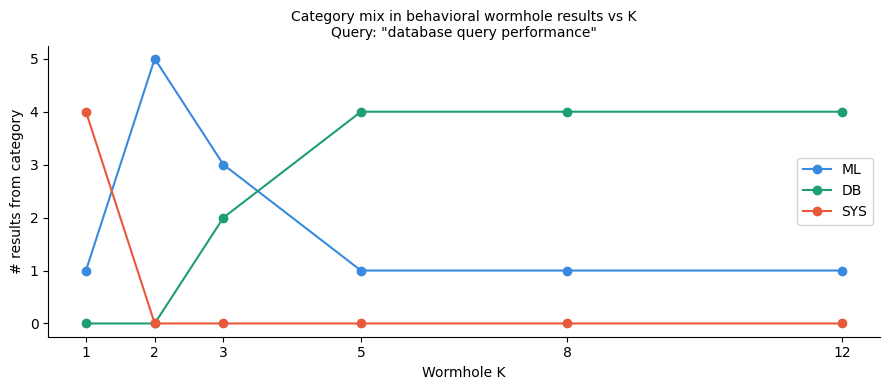

In [16]:
# Exercise 2 starter
query = 'database query performance'
k_values = [1, 2, 3, 5, 8, 12]

results_by_k = {}
for k in k_values:
    _, _, tgt = wormhole_traverse(query, 'sparse', 'behavioral', wormhole_k=k, top_k=5, verbose=False)
    results_by_k[k] = tgt

# Category distribution in target results vs K
fig, ax = plt.subplots(figsize=(9, 4))
for cat, color in CAT_COLORS.items():
    counts = [sum(1 for r in results_by_k[k] if df.loc[r[0],'category']==cat) for k in k_values]
    ax.plot(k_values, counts, marker='o', label=cat, color=color)
ax.set_xlabel('Wormhole K'); ax.set_ylabel('# results from category')
ax.set_title(f'Category mix in behavioral wormhole results vs K\nQuery: "{query}"', fontsize=10)
ax.legend(); ax.set_xticks(k_values)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Exercise 3 — Your own corpus

Replace the `CORPUS` list in Cell 2 with documents from your own domain (papers, product descriptions, support tickets, etc.). Re-run from Cell 3 onwards. What cross-space connections does the wormhole reveal that direct search misses?

In [17]:
# Exercise 3: add your own documents here and re-run the notebook from Cell 2.
MY_CORPUS = [
    {'id': 30, 'title': 'Your Document Title',
     'text': 'Your document text goes here...',
     'category': 'CUSTOM'},
    # add more ...
]
print('Add your documents to MY_CORPUS, append to CORPUS, then re-run from Cell 2.')

Add your documents to MY_CORPUS, append to CORPUS, then re-run from Cell 2.


---

## Summary

| Concept | Implementation |
|---|---|
| Sparse / Lexical space | `TfidfVectorizer` (BM25-style), `sparse_search()` |
| Dense / Semantic space | Pooled embeddings, `dense_search()` |
| Behavioral space | ALS matrix factorization on simulated interactions, `behavioral_search()` |
| Wormhole vector | `pool_embeddings()` — weighted average of top-K embeddings |
| Single-hop traversal | `wormhole_traverse()` |
| Multi-hop traversal | `multi_hop_traverse()` |

**Key takeaway:** each vector space captures a different *kind* of similarity. The wormhole technique lets you start a query in the space best suited to the user's phrasing, then slide over to whichever space best represents the *content* or *behaviour* you actually want to surface — without needing a joint embedding model.

-----------------
*Note:* This is a small / toy example to demonstrate the Wormhole Vector concept. Larger-scale examples with real data, a better `dense -> sparse` wormhole generation function, and benchmarks will be coming soon (the behavioral vector space, in particular, is a bit tricky from a dataset standpoint). More to come!